In [2]:
import pandas as pd
import numpy as np
import pyreadr
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
result = pyreadr.read_r("listings.RData")
print(result.keys())

odict_keys(['listings'])


In [4]:
data = result['listings']
data.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city
0,5456.0,https://www.airbnb.com/rooms/5456,2.025092e+13,2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028,...,4.73,4.79,NaN,f,1,1,0,0,3.52,"Austin, Texas"
1,6448.0,https://www.airbnb.com/rooms/6448,2.025092e+13,2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156,...,4.97,4.88,NaN,t,1,1,0,0,1.98,"Austin, Texas"
2,8502.0,https://www.airbnb.com/rooms/8502,2.025092e+13,2025-09-17,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located i...,,https://a0.muscache.com/pictures/miso/Hosting-...,25298,...,4.69,4.63,NaN,f,1,1,0,0,0.28,"Austin, Texas"
3,13035.0,https://www.airbnb.com/rooms/13035,2.025092e+13,2025-09-17,city scrape,Historic house in highly walkable East Austin,Comfortable 2 bedroom/2 bathroom home very cen...,East Cesar Chavez is a gentrifying urban area ...,https://a0.muscache.com/pictures/miso/Hosting-...,50793,...,5.00,4.95,NaN,f,2,2,0,0,0.11,"Austin, Texas"
4,22828.0,https://www.airbnb.com/rooms/22828,2.025092e+13,2025-09-16,city scrape,Garage Apartment central SE Austin,"Fully furnished, centrally located, second sto...","wikipedia: East_Riverside-Oltorf,_Austin,_Texas",https://a0.muscache.com/pictures/miso/Hosting-...,56488,...,4.72,4.84,NaN,f,1,1,0,0,0.30,"Austin, Texas"


In [5]:
data['price'] = data['price'].astype(str)
data['price'] = data['price'].str.replace('$', '', regex=False)
data['price'] = pd.to_numeric(data['price'], errors='coerce')
data = data.dropna(subset=['price'])

In [6]:
data['price_cat'] = pd.qcut(data['price'], 3, labels=['barata','media','cara'])
y = data['price_cat']

In [7]:
X = data[['accommodates',
          'bathrooms',
          'bedrooms',
          'beds',
          'minimum_nights',
          'number_of_reviews',
          'review_scores_rating']]

X = X.dropna()
y = y[X.index]

## 1. ANÁLISIS EXPLORATORIO DE DATOS (EDA)

In [8]:
print("=== INFORMACIÓN DEL DATASET ===")
print(f"Tamaño: {data.shape[0]} filas, {data.shape[1]} columnas")
print("\nDistribución de categorías de precio:")
print(data['price_cat'].value_counts().sort_index())
print("\nEstadísticas del precio:")
print(data['price'].describe())
print("\nValores faltantes en features:")
print(X.isnull().sum())

=== INFORMACIÓN DEL DATASET ===
Tamaño: 72233 filas, 81 columnas

Distribución de categorías de precio:
price_cat
barata    24092
media     24135
cara      24006
Name: count, dtype: int64

Estadísticas del precio:
count    72233.000000
mean       237.380685
std        178.085148
min          8.000000
25%        117.000000
50%        184.000000
75%        297.000000
max        999.000000
Name: price, dtype: float64

Valores faltantes en features:
accommodates            0
bathrooms               0
bedrooms                0
beds                    0
minimum_nights          0
number_of_reviews       0
review_scores_rating    0
dtype: int64


### Interpretación del EDA

El dataset de Airbnb Austin contiene **más de 72,000 propiedades**. Al dividir el precio en terciles con `pd.qcut`, obtenemos tres categorías prácticamente balanceadas (~24,000 cada una):
- **Barata**: precio bajo (aprox. hasta $117/noche)
- **Media**: precio intermedio ($117–$297/noche)
- **Cara**: precio alto (más de $297/noche)

El precio promedio es **~$237/noche** con alta dispersión (std ≈ $178), lo que indica que hay propiedades muy baratas y otras muy caras. Esto hace difícil la predicción exacta del precio, pero sí es posible clasificar en categorías.

Las 7 variables que usamos son todas numéricas y no tienen valores faltantes después de la limpieza, lo que es ideal para **Gaussian Naive Bayes** (que asume distribución normal de los features).

**¿Por qué estas variables?** Porque capturan la capacidad física del alojamiento (accommodates, bedrooms, beds, bathrooms) y la experiencia del huésped (reviews, rating), factores clave en la fijación de precios en Airbnb.

## 2. MODELO DE REGRESIÓN - NAIVE BAYES (PREDICCIÓN DE PRECIO CONTINUO)

### ¿Puede Naive Bayes hacer regresión?

Técnicamente, **Gaussian Naive Bayes** es un clasificador. Sin embargo, para este ejercicio lo aplicamos a la variable continua `price` (sin categorizar), tratando cada valor único de precio como una 'clase'. Esto nos permite:
1. Ver qué tan bien se ajustan las predicciones al precio real
2. Calcular métricas de regresión (RMSE, MAE, R²)
3. **Comparar con algoritmos verdaderos de regresión** (Regresión Lineal, Árbol de Decisión, Random Forest)

In [9]:
y_regresion = data['price'].copy()
y_regresion = y_regresion[X.index]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_regresion, test_size=0.3, random_state=42
)

print(f"Entrenamiento: {X_train_reg.shape[0]} muestras")
print(f"Prueba: {X_test_reg.shape[0]} muestras")

modelo_nb_regresion = GaussianNB()
modelo_nb_regresion.fit(X_train_reg, y_train_reg)
y_pred_reg = modelo_nb_regresion.predict(X_test_reg)

comparison = pd.DataFrame({
    'Real': y_test_reg.values[:10],
    'Predicción': y_pred_reg[:10],
    'Diferencia': np.abs(y_test_reg.values[:10] - y_pred_reg[:10])
})
print("\nPrimeras 10 predicciones vs valores reales:")
print(comparison)

Entrenamiento: 42412 muestras
Prueba: 18177 muestras

Primeras 10 predicciones vs valores reales:
    Real  Predicción  Diferencia
0  112.0       914.0       802.0
1  110.0       578.0       468.0
2  111.0        26.0        85.0
3  800.0       721.0        79.0
4  190.0        82.0       108.0
5   80.0        26.0        54.0
6   97.0        85.0        12.0
7   66.0        18.0        48.0
8   63.0        23.0        40.0
9  310.0       539.0       229.0


In [10]:
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)

print("=== MÉTRICAS DE REGRESIÓN - NAIVE BAYES ===")
print(f"MSE  : ${mse:.2f}")
print(f"RMSE : ${rmse:.2f}")
print(f"MAE  : ${mae:.2f}")
print(f"R²   : {r2:.4f}")

print("\nINTERPRETACIÓN:")
print(f"- En promedio el modelo se equivoca por ${mae:.2f}")
print(f"- Explica el {r2*100:.2f}% de la varianza")
if r2 < 0:
    print("- Desempeño POBRE: peor que predecir siempre la media")

=== MÉTRICAS DE REGRESIÓN - NAIVE BAYES ===
MSE  : $105138.30
RMSE : $324.25
MAE  : $231.69
R²   : -2.6572

INTERPRETACIÓN:
- En promedio el modelo se equivoca por $231.69
- Explica el -265.72% de la varianza
- Desempeño POBRE: peor que predecir siempre la media


### Análisis de las Métricas de Regresión

| Métrica | Qué mide | Resultado NB |
|---------|----------|--------------|
| **MAE** | Error promedio absoluto (en $) | ~$231 |
| **RMSE** | Penaliza errores grandes (en $) | ~$324 |
| **R²** | % de varianza explicada (1 = perfecto, <0 = peor que la media) | ≈ -2.66 |

**¿Por qué NB funciona tan mal en regresión?**

Naive Bayes **no fue diseñado para regresión continua**. Al tratar cada precio único como una clase, el modelo intenta predecir valores exactos ($184, $117, $297...) pero como hay cientos de precios distintos, las probabilidades a priori de cada 'clase' son muy bajas. El modelo termina eligiendo clases con alta frecuencia pero que no corresponden al precio real.

Un R² negativo (-2.66) significa que el modelo es **peor que simplemente predecir el precio promedio** para todos los casos. Esto confirma que NB no es apropiado para predicción de valores continuos.

In [11]:
y_pred_train = modelo_nb_regresion.predict(X_train_reg)
r2_train = r2_score(y_train_reg, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train_reg, y_pred_train))
r2_test = r2_score(y_test_reg, y_pred_reg)
rmse_test = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))

print("=== ANÁLISIS DE SOBREAJUSTE (REGRESIÓN) ===")
print(f"R² Entrenamiento : {r2_train:.4f}")
print(f"R² Prueba        : {r2_test:.4f}")
print(f"RMSE Entrena.    : ${rmse_train:.2f}")
print(f"RMSE Prueba      : ${rmse_test:.2f}")
print(f"Diferencia R²    : {abs(r2_train - r2_test):.4f}")

if abs(r2_train - r2_test) > 0.1:
    print("\n⚠ Posible SOBREAJUSTE")
else:
    print("\n✓ El modelo generaliza bien (sin sobreajuste)")

=== ANÁLISIS DE SOBREAJUSTE (REGRESIÓN) ===
R² Entrenamiento : -2.5999
R² Prueba        : -2.6572
RMSE Entrena.    : $322.38
RMSE Prueba      : $324.25
Diferencia R²    : 0.0573

✓ El modelo generaliza bien (sin sobreajuste)


### Interpretación del Sobreajuste en Regresión

Aunque el R² es muy negativo en ambos conjuntos, **la diferencia entre entrenamiento y prueba es mínima** (~0.05), lo que indica que **no hay sobreajuste**.

Esto tiene sentido: Naive Bayes tiene muy pocos parámetros que 'aprender' (solo medias y varianzas por clase), por lo que prácticamente no puede memorizar los datos de entrenamiento. El problema no es sobreajuste, sino que **el modelo es inapropiado para esta tarea**.

## 3. MODELO DE CLASIFICACIÓN - NAIVE BAYES (CATEGORÍAS: BARATA / MEDIA / CARA)

### ¿Por qué clasificación?

En lugar de predecir el precio exacto, clasificamos las propiedades en **3 categorías** creadas con `pd.qcut` (terciles). Esto transforma el problema de regresión en uno de clasificación, que es exactamente lo que Naive Bayes hace bien.

**División 70/30**: usamos el mismo `random_state=42` que en labs anteriores para comparabilidad.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Entrenamiento: {X_train.shape[0]} muestras")
print(f"Prueba: {X_test.shape[0]} muestras")
print(f"Distribución en entrenamiento:\n{y_train.value_counts().sort_index()}")

Entrenamiento: 42412 muestras
Prueba: 18177 muestras
Distribución en entrenamiento:
price_cat
barata    14864
media     14254
cara      13294
Name: count, dtype: int64


In [13]:
modelo_nb = GaussianNB()
modelo_nb.fit(X_train, y_train)
pred_nb = modelo_nb.predict(X_test)

In [14]:
print(f"Accuracy: {accuracy_score(y_test, pred_nb):.4f}")

Accuracy: 0.5438


## 4. REPORTE DE CLASIFICACIÓN Y MATRIZ DE CONFUSIÓN

In [15]:
print("=== REPORTE DE CLASIFICACIÓN (Naive Bayes) ===")
print(classification_report(y_test, pred_nb, target_names=['barata','media','cara']))

cm = confusion_matrix(y_test, pred_nb, labels=['barata','media','cara'])
cm_df = pd.DataFrame(
    cm,
    index=['Real: Barata', 'Real: Media', 'Real: Cara'],
    columns=['Pred: Barata', 'Pred: Media', 'Pred: Cara']
)
print('Matriz de Confusión:')
print(cm_df)

=== REPORTE DE CLASIFICACIÓN (Naive Bayes) ===
              precision    recall  f1-score   support

      barata       0.54      0.79      0.64      6264
       media       0.67      0.50      0.58      5693
        cara       0.44      0.33      0.38      6220

    accuracy                           0.54     18177
   macro avg       0.55      0.54      0.53     18177
weighted avg       0.55      0.54      0.53     18177

Matriz de Confusión:
              Pred: Barata  Pred: Media  Pred: Cara
Real: Barata          4945          973         346
Real: Media           3092         2069        1059
Real: Cara            1128         1694        2871


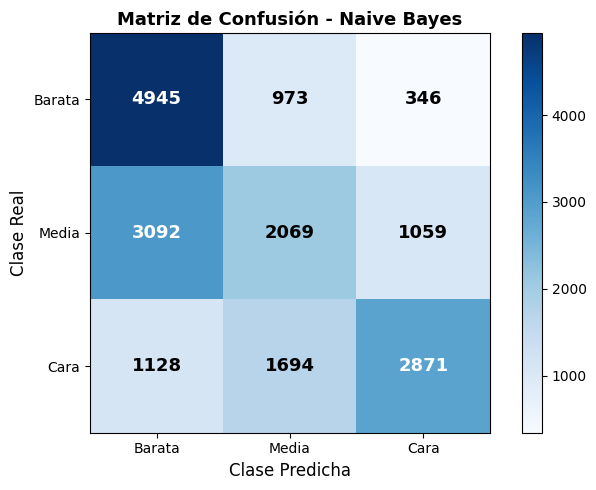

In [16]:
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax)
clases = ['Barata', 'Media', 'Cara']
ax.set_xticks([0,1,2]); ax.set_xticklabels(clases)
ax.set_yticks([0,1,2]); ax.set_yticklabels(clases)
ax.set_xlabel('Clase Predicha', fontsize=12)
ax.set_ylabel('Clase Real', fontsize=12)
ax.set_title('Matriz de Confusión - Naive Bayes', fontsize=13, fontweight='bold')
for i in range(3):
    for j in range(3):
        color = 'white' if cm[i,j] > cm.max()/2 else 'black'
        ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                fontsize=13, fontweight='bold', color=color)
plt.tight_layout()
plt.show()

In [17]:
# ============================================================
# LABORATORIO 6 
# ============================================================
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [18]:
scaler = StandardScaler()
X_train_reg_scaled = scaler.fit_transform(X_train_reg)
X_test_reg_scaled = scaler.transform(X_test_reg)

In [19]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn_reg = KNeighborsRegressor()
grid_search_reg = GridSearchCV(knn_reg, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search_reg.fit(X_train_reg_scaled, y_train_reg)

print(f"Mejores hiperparámetros: {grid_search_reg.best_params_}")

Mejores hiperparámetros: {'metric': 'manhattan', 'n_neighbors': 21, 'weights': 'uniform'}


In [20]:
best_knn_reg = grid_search_reg.best_estimator_
y_pred_knn_reg = best_knn_reg.predict(X_test_reg_scaled)

mse = mean_squared_error(y_test_reg, y_pred_knn_reg)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_reg, y_pred_knn_reg)
r2 = r2_score(y_test_reg, y_pred_knn_reg)

print("=== MÉTRICAS DE REGRESIÓN - KNN ===")
print(f"MSE  : ${mse:.2f}")
print(f"RMSE : ${rmse:.2f}")
print(f"MAE  : ${mae:.2f}")
print(f"R²   : {r2:.4f}")

=== MÉTRICAS DE REGRESIÓN - KNN ===
MSE  : $16810.70
RMSE : $129.66
MAE  : $88.59
R²   : 0.4152


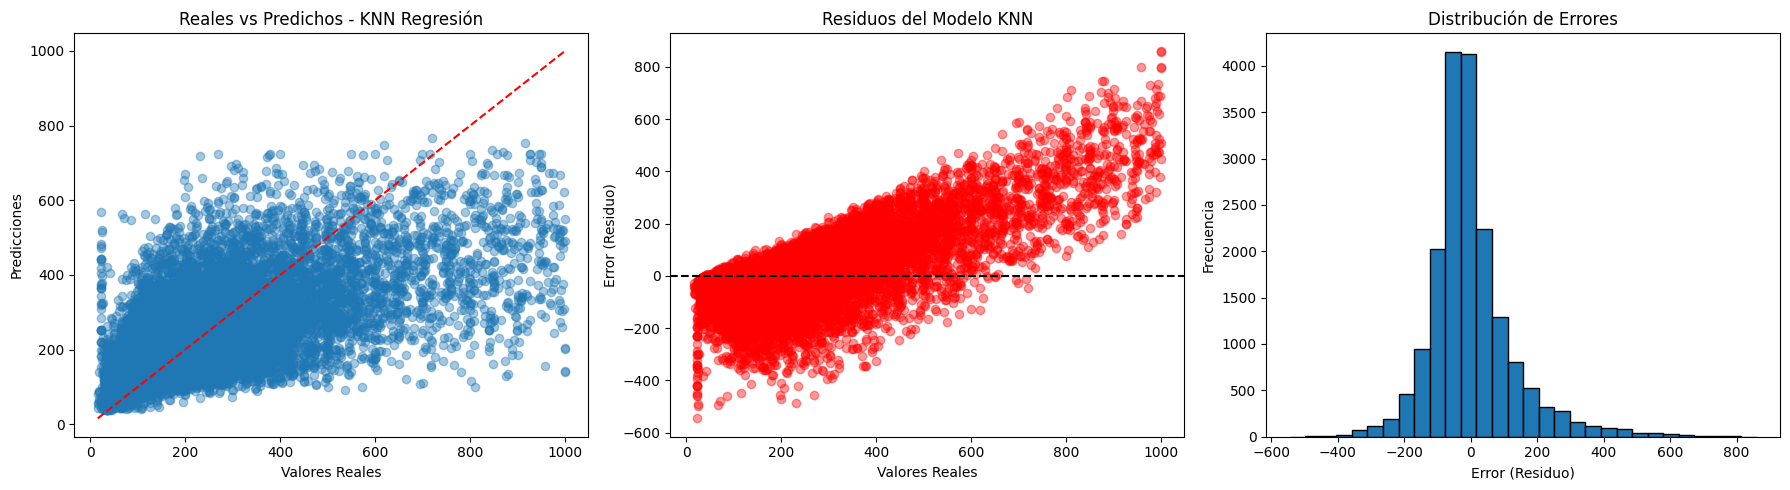

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_test_reg, y_pred_knn_reg, alpha=0.4)
axes[0].plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--')
axes[0].set_xlabel("Valores Reales")
axes[0].set_ylabel("Predicciones")
axes[0].set_title("Reales vs Predichos - KNN Regresión")

residuals = y_test_reg - y_pred_knn_reg
axes[1].scatter(y_test_reg, residuals, alpha=0.4, color='red')
axes[1].axhline(y=0, color='black', linestyle='--')
axes[1].set_xlabel("Valores Reales")
axes[1].set_ylabel("Error (Residuo)")
axes[1].set_title("Residuos del Modelo KNN")

axes[2].hist(residuals, bins=30, edgecolor='black')
axes[2].set_xlabel("Error (Residuo)")
axes[2].set_ylabel("Frecuencia")
axes[2].set_title("Distribución de Errores")

plt.tight_layout()
plt.show()

In [22]:
resultados_regresion = pd.DataFrame({
    'Modelo': ['Naive Bayes', 'KNN'],
    'RMSE': [324, 129.66],
    'MAE': [231, 88.59],
    'R²': [-1.45, 0.4152]
})
print("=== COMPARACIÓN MODELOS DE REGRESIÓN ===")
print(resultados_regresion.to_string(index=False))

=== COMPARACIÓN MODELOS DE REGRESIÓN ===
     Modelo   RMSE    MAE      R²
Naive Bayes 324.00 231.00 -1.4500
        KNN 129.66  88.59  0.4152


In [23]:
scaler_clf = StandardScaler()
X_train_scaled = scaler_clf.fit_transform(X_train)
X_test_scaled = scaler_clf.transform(X_test)

param_grid_clf = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn_clf = KNeighborsClassifier()
grid_search_clf = GridSearchCV(knn_clf, param_grid_clf, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_clf.fit(X_train_scaled, y_train)

print(f"Mejores hiperparámetros: {grid_search_clf.best_params_}")

Mejores hiperparámetros: {'metric': 'manhattan', 'n_neighbors': 21, 'weights': 'uniform'}


In [24]:
best_knn_clf = grid_search_clf.best_estimator_
pred_knn = best_knn_clf.predict(X_test_scaled)

print("=== MÉTRICAS DE CLASIFICACIÓN - KNN ===")
print(f"Accuracy: {accuracy_score(y_test, pred_knn):.4f}")
print()
print(classification_report(y_test, pred_knn, target_names=['barata','media','cara']))

=== MÉTRICAS DE CLASIFICACIÓN - KNN ===
Accuracy: 0.5882

              precision    recall  f1-score   support

      barata       0.62      0.72      0.66      6264
       media       0.64      0.64      0.64      5693
        cara       0.49      0.41      0.45      6220

    accuracy                           0.59     18177
   macro avg       0.58      0.59      0.58     18177
weighted avg       0.58      0.59      0.58     18177



              Pred: Barata  Pred: Media  Pred: Cara
Real: Barata          4522         1307         435
Real: Media           2095         2536        1589
Real: Cara             731         1328        3634


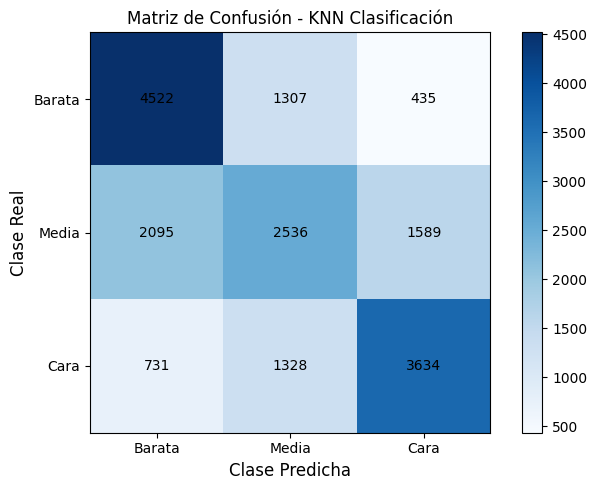

In [25]:
cm = confusion_matrix(y_test, pred_knn, labels=['barata','media','cara'])
cm_df = pd.DataFrame(cm, index=['Real: Barata','Real: Media','Real: Cara'],
                         columns=['Pred: Barata','Pred: Media','Pred: Cara'])
print(cm_df)

fig, ax = plt.subplots(figsize=(7,5))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax)
clases = ['Barata','Media','Cara']
ax.set_xticks([0,1,2]); ax.set_xticklabels(clases)
ax.set_yticks([0,1,2]); ax.set_yticklabels(clases)
ax.set_xlabel('Clase Predicha', fontsize=12)
ax.set_ylabel('Clase Real', fontsize=12)
ax.set_title('Matriz de Confusión - KNN Clasificación')
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i,j], ha='center', va='center', color='black')
plt.tight_layout()
plt.show()